### Importación de datos



In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación



In [27]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

ingresos = {
    "Tienda 1": round(tienda["Precio"].sum()),
    "Tienda 2": round(tienda2["Precio"].sum()),
    "Tienda 3": round(tienda3["Precio"].sum()),
    "Tienda 4": round(tienda4["Precio"].sum()),
}

ingresos_df = pd.DataFrame(ingresos.items(), columns=["Tienda", "Ingreso Total (COP)"])
ingresos_df = ingresos_df.sort_values(by="Ingreso Total (COP)", ascending=False)

ingresos_df["Ingreso Total (COP)"] = ingresos_df["Ingreso Total (COP)"].apply(lambda x: "${:,.0f} COP".format(x))

print("💵 Ingreso total por tienda:")
print(ingresos_df)


💵 Ingreso total por tienda:
     Tienda Ingreso Total (COP)
0  Tienda 1  $1,150,880,400 COP
1  Tienda 2  $1,116,343,500 COP
2  Tienda 3  $1,098,019,600 COP
3  Tienda 4  $1,038,375,700 COP


# 2. Ventas por categoría

In [28]:
import pandas as pd
url1 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url1)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

def contar_categorias(df, nombre_tienda):
    conteo = df["Categoría del Producto"].value_counts().reset_index()
    conteo.columns = ["Categoría", "Cantidad de ventas"]
    conteo["Tienda"] = nombre_tienda
    return conteo

cat_tienda1 = contar_categorias(tienda, "Tienda 1")
cat_tienda2 = contar_categorias(tienda2, "Tienda 2")
cat_tienda3 = contar_categorias(tienda3, "Tienda 3")
cat_tienda4 = contar_categorias(tienda4, "Tienda 4")

categorias_df = pd.concat([cat_tienda1, cat_tienda2, cat_tienda3, cat_tienda4], ignore_index=True)

print("🛒 Cantidad de productos vendidos por categoría en cada tienda:")
print(categorias_df)


🛒 Cantidad de productos vendidos por categoría en cada tienda:
                  Categoría  Cantidad de ventas    Tienda
0                   Muebles                 465  Tienda 1
1              Electrónicos                 448  Tienda 1
2                  Juguetes                 324  Tienda 1
3         Electrodomésticos                 312  Tienda 1
4      Deportes y diversión                 284  Tienda 1
5    Instrumentos musicales                 182  Tienda 1
6                    Libros                 173  Tienda 1
7   Artículos para el hogar                 171  Tienda 1
8                   Muebles                 442  Tienda 2
9              Electrónicos                 422  Tienda 2
10                 Juguetes                 313  Tienda 2
11        Electrodomésticos                 305  Tienda 2
12     Deportes y diversión                 275  Tienda 2
13   Instrumentos musicales                 224  Tienda 2
14                   Libros                 197  Tienda 2
15  Artíc

# 3. Calificación promedio de la tienda


In [29]:
import pandas as pd

url1 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url1)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

calificaciones = {
    "Tienda 1": round(tienda["Calificación"].mean(), 2),
    "Tienda 2": round(tienda2["Calificación"].mean(), 2),
    "Tienda 3": round(tienda3["Calificación"].mean(), 2),
    "Tienda 4": round(tienda4["Calificación"].mean(), 2),
}

calificaciones_df = pd.DataFrame(calificaciones.items(), columns=["Tienda", "Calificación Promedio"])

calificaciones_df = calificaciones_df.sort_values(by="Calificación Promedio", ascending=False)

print("🌟 Calificaciones promedio de los clientes por tienda:")
print(calificaciones_df)


🌟 Calificaciones promedio de los clientes por tienda:
     Tienda  Calificación Promedio
2  Tienda 3                   4.05
1  Tienda 2                   4.04
3  Tienda 4                   4.00
0  Tienda 1                   3.98


# 4. Productos más y menos vendidos

In [31]:
import pandas as pd

url1 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url1)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

def productos_vendidos(df, nombre_tienda):
    conteo_productos = df["Producto"].value_counts().reset_index()
    conteo_productos.columns = ["Producto", "Cantidad Vendida"]
    conteo_productos["Tienda"] = nombre_tienda
    return conteo_productos

productos_tienda1 = productos_vendidos(tienda, "Tienda 1")
productos_tienda2 = productos_vendidos(tienda2, "Tienda 2")
productos_tienda3 = productos_vendidos(tienda3, "Tienda 3")
productos_tienda4 = productos_vendidos(tienda4, "Tienda 4")

productos_df = pd.concat([productos_tienda1, productos_tienda2, productos_tienda3, productos_tienda4], ignore_index=True)

def productos_mas_vendidos(tienda_df):
    top_ventas = tienda_df.nlargest(10, "Cantidad Vendida")
    print(f"🔝 Productos más vendidos en {tienda_df['Tienda'].iloc[0]}:")
    print(top_ventas[['Producto', 'Cantidad Vendida']], "\n")

def productos_menos_vendidos(tienda_df):
    bottom_ventas = tienda_df.nsmallest(10, "Cantidad Vendida")
    print(f"🔻 Productos menos vendidos en {tienda_df['Tienda'].iloc[0]}:")
    print(bottom_ventas[['Producto', 'Cantidad Vendida']], "\n")

for tienda_nombre in ["Tienda 1", "Tienda 2", "Tienda 3", "Tienda 4"]:
    tienda_df = productos_df[productos_df["Tienda"] == tienda_nombre]
    productos_mas_vendidos(tienda_df)
    productos_menos_vendidos(tienda_df)


🔝 Productos más vendidos en Tienda 1:
                  Producto  Cantidad Vendida
0               Microondas                60
1            TV LED UHD 4K                60
2                  Armario                60
3         Secadora de ropa                58
4            Mesa de noche                56
5  Bloques de construcción                56
6      Balón de baloncesto                55
7                Bicicleta                54
8             Vaso térmico                54
9             Refrigerador                54 

🔻 Productos menos vendidos en Tienda 1:
                       Producto  Cantidad Vendida
49    Auriculares con micrófono                33
50                 Celular ABXY                33
48              Olla de presión                35
47                    Pandereta                36
45                      Mochila                39
46  Ciencia de datos con Python                39
40            Asistente virtual                40
41                  Muñec

# 5. Envío promedio por tienda

In [33]:
import pandas as pd

url1 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url1)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

costo_envio_promedio = {
    "Tienda 1": round(tienda["Costo de envío"].mean(), 0),
    "Tienda 2": round(tienda2["Costo de envío"].mean(), 0),
    "Tienda 3": round(tienda3["Costo de envío"].mean(), 0),
    "Tienda 4": round(tienda4["Costo de envío"].mean(), 0),
}

costo_envio_df = pd.DataFrame(costo_envio_promedio.items(), columns=["Tienda", "Costo de Envío Promedio (COP)"])

costo_envio_df["Costo de Envío Promedio (COP)"] = costo_envio_df["Costo de Envío Promedio (COP)"].apply(lambda x: f"${x:,.0f}")

costo_envio_df = costo_envio_df.sort_values(by="Costo de Envío Promedio (COP)", ascending=False)

print("💰 Costo de envío promedio por tienda (en pesos colombianos):")
print(costo_envio_df)


💰 Costo de envío promedio por tienda (en pesos colombianos):
     Tienda Costo de Envío Promedio (COP)
0  Tienda 1                       $26,019
1  Tienda 2                       $25,216
2  Tienda 3                       $24,806
3  Tienda 4                       $23,459


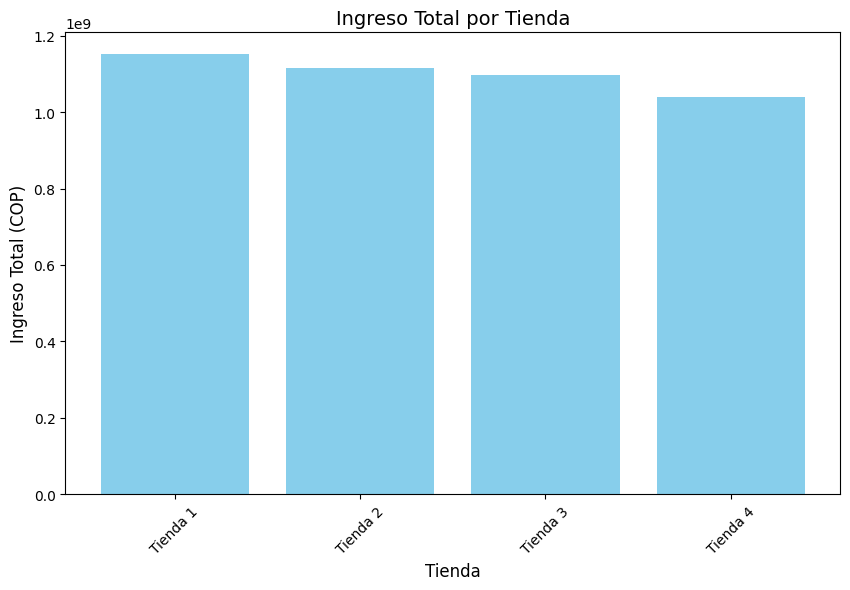

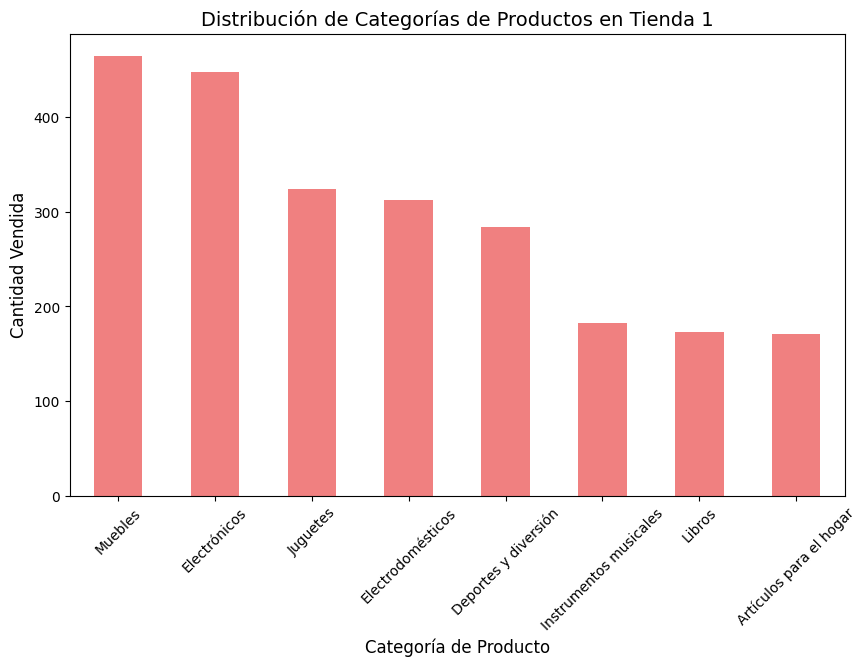

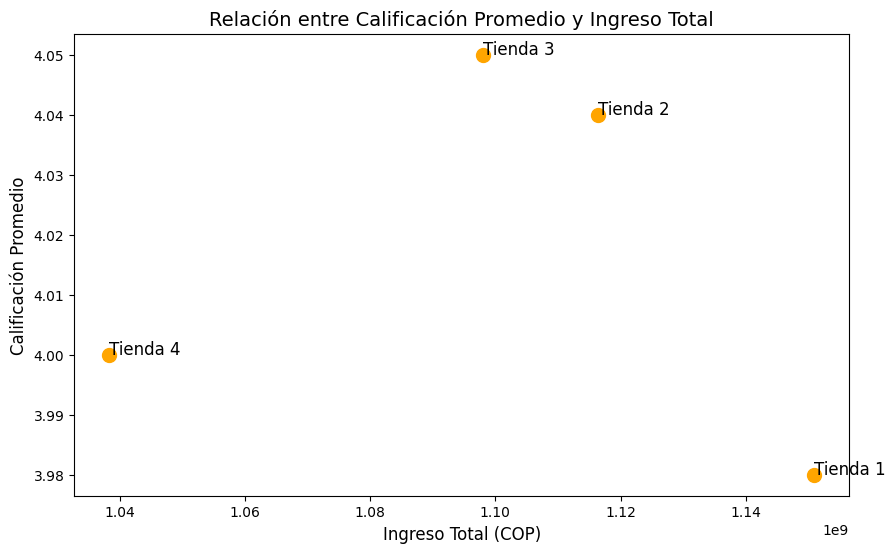

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

url1 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url1)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

ingresos_tienda = {
    "Tienda 1": round(tienda["Precio"].sum(), 2),
    "Tienda 2": round(tienda2["Precio"].sum(), 2),
    "Tienda 3": round(tienda3["Precio"].sum(), 2),
    "Tienda 4": round(tienda4["Precio"].sum(), 2),
}

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.bar(ingresos_tienda.keys(), ingresos_tienda.values(), color='skyblue')
ax.set_title("Ingreso Total por Tienda", fontsize=14)
ax.set_xlabel("Tienda", fontsize=12)
ax.set_ylabel("Ingreso Total (COP)", fontsize=12)
ax.tick_params(axis='x', rotation=45)
plt.show()

categorias_tienda1 = tienda["Categoría del Producto"].value_counts()
categorias_tienda2 = tienda2["Categoría del Producto"].value_counts()
categorias_tienda3 = tienda3["Categoría del Producto"].value_counts()
categorias_tienda4 = tienda4["Categoría del Producto"].value_counts()

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
categorias_tienda1.plot(kind='bar', color='lightcoral', ax=ax)
ax.set_title("Distribución de Categorías de Productos en Tienda 1", fontsize=14)
ax.set_xlabel("Categoría de Producto", fontsize=12)
ax.set_ylabel("Cantidad Vendida", fontsize=12)
ax.tick_params(axis='x', rotation=45)
plt.show()

calificacion_promedio = {
    "Tienda 1": round(tienda["Calificación"].mean(), 2),
    "Tienda 2": round(tienda2["Calificación"].mean(), 2),
    "Tienda 3": round(tienda3["Calificación"].mean(), 2),
    "Tienda 4": round(tienda4["Calificación"].mean(), 2),
}

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.scatter(ingresos_tienda.values(), calificacion_promedio.values(), color='orange', s=100)
ax.set_title("Relación entre Calificación Promedio y Ingreso Total", fontsize=14)
ax.set_xlabel("Ingreso Total (COP)", fontsize=12)
ax.set_ylabel("Calificación Promedio", fontsize=12)
for i, txt in enumerate(ingresos_tienda.keys()):
    ax.annotate(txt, (ingresos_tienda[txt], calificacion_promedio[txt]), fontsize=12)
plt.show()
